In [ ]:
"""
Pupil Size Data Cleaning Pipeline — 5-Model Ensemble Strategy
==============================================================
OVERVIEW OF THE STRATEGY
-------------------------
We generate 5 distinct synthetic datasets and pretrain one separate model
on each. This gives us 5 independently-pretrained models that can later be
fine-tuned or used as an ensemble on real data.

  Dataset / Model 1  →  SMALL artifacts   (blinks short, spikes small)
  Dataset / Model 2  →  MEDIUM artifacts  (blinks moderate, spikes moderate)
  Dataset / Model 3  →  LARGE artifacts   (blinks long,   spikes large)
  Dataset / Model 4  →  EXTREME artifacts (maximum noise and corruption)
  Dataset / Model 5  →  ALL SIZES mixed   (random mix of all the above)

HOW TO CHOOSE ARTIFACT SIZE
-----------------------------
Set the variable ARTIFACT_SIZE at the top of Section 1b to one of:
    "small"   → Dataset 1
    "medium"  → Dataset 2
    "large"   → Dataset 3
    "extreme" → Dataset 4
    "all"     → Dataset 5  (mix of all sizes)

Dependencies: numpy, torch, matplotlib, scikit-learn
Install: pip install torch numpy matplotlib scikit-learn
"""

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os


# ═══════════════════════════════════════════════════════════════════════════════
# 1a. ARTIFACT SIZE PROFILES
#     Each profile defines the ranges used by add_artifacts().
#     Edit these dictionaries to tune what each "size" means.
# ═══════════════════════════════════════════════════════════════════════════════

ARTIFACT_PROFILES = {
    # ── Dataset / Model 1 ──────────────────────────────────────────────────────
    "small": {
        "description": "Dataset 1 — SMALL artifacts (short blinks, tiny spikes, low noise)",
        "gaussian_noise_std": (0.005, 0.015),   # very low noise floor
        "n_blinks":           (0, 2),            # 0–1 blinks
        "blink_length":       (3,  8),           # very short blinks (3–7 samples)
        "n_spikes":           (0, 3),            # 0–2 spikes
        "spike_amplitude":    (0.05, 0.15),      # barely visible spikes
        "data_loss_prob":     0.1,               # 10 % chance of a data-loss gap
        "data_loss_length":   (1,  4),           # tiny gap
    },

    # ── Dataset / Model 2 ──────────────────────────────────────────────────────
    "medium": {
        "description": "Dataset 2 — MEDIUM artifacts (moderate blinks, moderate spikes, normal noise)",
        "gaussian_noise_std": (0.01, 0.03),      # normal noise floor (original range)
        "n_blinks":           (0, 4),            # 0–3 blinks
        "blink_length":       (5,  18),          # original blink range
        "n_spikes":           (0, 5),            # 0–4 spikes
        "spike_amplitude":    (0.2, 0.5),        # original spike amplitude
        "data_loss_prob":     0.3,               # 30 % chance
        "data_loss_length":   (2,  8),           # original gap range
    },

    # ── Dataset / Model 3 ──────────────────────────────────────────────────────
    "large": {
        "description": "Dataset 3 — LARGE artifacts (long blinks, big spikes, elevated noise)",
        "gaussian_noise_std": (0.03, 0.07),      # elevated noise
        "n_blinks":           (2,  7),           # more frequent blinks
        "blink_length":       (15, 40),          # long blinks
        "n_spikes":           (3,  9),           # many spikes
        "spike_amplitude":    (0.4, 0.9),        # large spikes
        "data_loss_prob":     0.5,               # 50 % chance
        "data_loss_length":   (5,  20),          # longer gaps
    },

    # ── Dataset / Model 4 ──────────────────────────────────────────────────────
    "extreme": {
        "description": "Dataset 4 — EXTREME artifacts (maximum corruption, heavy noise)",
        "gaussian_noise_std": (0.07, 0.15),      # very heavy noise
        "n_blinks":           (4,  12),          # many long blinks
        "blink_length":       (25, 60),          # very long blinks
        "n_spikes":           (5,  15),          # very many spikes
        "spike_amplitude":    (0.6, 1.5),        # massive spikes
        "data_loss_prob":     0.7,               # 70 % chance
        "data_loss_length":   (10, 40),          # large gaps
    },
}

# ═══════════════════════════════════════════════════════════════════════════════
# 1b. *** CHOOSE WHICH DATASET / MODEL YOU ARE BUILDING HERE ***
#
#     Set ARTIFACT_SIZE to one of:
#         "small"   → generates Dataset 1, trains Model 1
#         "medium"  → generates Dataset 2, trains Model 2
#         "large"   → generates Dataset 3, trains Model 3
#         "extreme" → generates Dataset 4, trains Model 4
#         "all"     → generates Dataset 5, trains Model 5
#                     (randomly mixes all four profiles per sample)
# ═══════════════════════════════════════════════════════════════════════════════

ARTIFACT_SIZE = "all"   # ← CHANGE THIS to switch dataset / model

# Validate choice
assert ARTIFACT_SIZE in ("small", "medium", "large", "extreme", "all"), (
    f"ARTIFACT_SIZE must be one of 'small', 'medium', 'large', 'extreme', 'all'. "
    f"Got: '{ARTIFACT_SIZE}'"
)

# Derive dataset index and save name from ARTIFACT_SIZE
_SIZE_TO_MODEL_INDEX = {"small": 1, "medium": 2, "large": 3, "extreme": 4, "all": 5}
MODEL_INDEX = _SIZE_TO_MODEL_INDEX[ARTIFACT_SIZE]

DATASET_SAVE_PATH = f"dataset_model{MODEL_INDEX}_{ARTIFACT_SIZE}.npz"
MODEL_SAVE_PATH   = f"model{MODEL_INDEX}_{ARTIFACT_SIZE}.pt"

if ARTIFACT_SIZE == "all":
    ACTIVE_PROFILE_DESCRIPTION = (
        "Dataset 5 — ALL SIZES mixed (each sample randomly drawn from one "
        "of the four artifact profiles: small / medium / large / extreme)"
    )
else:
    ACTIVE_PROFILE_DESCRIPTION = ARTIFACT_PROFILES[ARTIFACT_SIZE]["description"]

print("=" * 70)
print(f"  ACTIVE CONFIGURATION")
print(f"  {ACTIVE_PROFILE_DESCRIPTION}")
print(f"  Dataset save path : {DATASET_SAVE_PATH}")
print(f"  Model  save path  : {MODEL_SAVE_PATH}")
print("=" * 70)


# ─────────────────────────────────────────────
# 2. SYNTHETIC DATA GENERATION
# ─────────────────────────────────────────────

def generate_pupil_signal(n: int = 300, n_flashes: int = None, rng=None) -> np.ndarray:
    """
    Clean signal = baseline with sharp drops + smooth exponential recovery.
    The light reflex IS part of the clean signal.
    """
    if rng is None:
        rng = np.random.default_rng()
    if n_flashes is None:
        n_flashes = rng.integers(2, 6)

    signal = np.ones(n, dtype=np.float32)

    min_gap   = n // (n_flashes + 1)
    positions = []
    for i in range(n_flashes):
        low  = int(n * 0.05) + i * min_gap
        high = low + min_gap
        high = min(high, int(n * 0.92))
        if low >= high:
            continue
        positions.append(rng.integers(low, high))

    for pos in positions:
        drop_depth   = rng.uniform(0.05, 0.55)
        recovery_tau = rng.uniform(n * 0.03, n * 0.12)
        t            = np.arange(n - pos, dtype=np.float32)
        recovery     = 1.0 - drop_depth * np.exp(-t / recovery_tau)
        signal[pos:] = np.minimum(signal[pos:], recovery)
        signal[pos]  = 1.0 - drop_depth

    drift  = rng.uniform(-0.02, 0.02) * np.linspace(0, 1, n)
    signal = np.clip(signal + drift.astype(np.float32), 0.0, 1.3)
    return signal


def add_artifacts(signal: np.ndarray, profile: dict, rng=None) -> np.ndarray:
    """
    Add artifacts ON TOP of the clean light-reflex signal.
    Artifact severity is controlled entirely by `profile` (one of ARTIFACT_PROFILES).

    Args:
        signal:  Clean pupil signal, shape (L,).
        profile: One of the dictionaries in ARTIFACT_PROFILES.
        rng:     Numpy random generator.
    """
    if rng is None:
        rng = np.random.default_rng()

    noisy = signal.copy()
    n     = len(signal)

    # 1. Gaussian noise
    noise_std = rng.uniform(*profile["gaussian_noise_std"])
    noisy    += rng.normal(0, noise_std, n).astype(np.float32)

    # 2. Blink artifacts — V-shape dips
    n_blinks = rng.integers(*profile["n_blinks"])
    for _ in range(n_blinks):
        blink_len = rng.integers(*profile["blink_length"])
        if n - blink_len <= 0:
            continue
        pos  = rng.integers(0, n - blink_len)
        end  = min(pos + blink_len, n)
        half = (end - pos) // 2
        dip  = np.concatenate([
            np.linspace(1.0, 0.05, half),
            np.linspace(0.05, 1.0, end - pos - half),
        ]).astype(np.float32)
        noisy[pos:end] *= dip

    # 3. Spikes (1–2 samples wide)
    n_spikes = rng.integers(*profile["n_spikes"])
    for idx in rng.integers(0, n, size=n_spikes):
        amplitude   = rng.uniform(*profile["spike_amplitude"])
        noisy[idx] += rng.choice([-1, 1]) * amplitude

    # 4. Data-loss gaps
    if rng.random() < profile["data_loss_prob"]:
        gap_len = rng.integers(*profile["data_loss_length"])
        if n - gap_len > 0:
            pos              = rng.integers(0, n - gap_len)
            noisy[pos:pos + gap_len] = rng.uniform(0.0, 0.05)

    return np.clip(noisy, 0.0, 1.5).astype(np.float32)


def generate_dataset(
    artifact_size: str = ARTIFACT_SIZE,
    n_samples:     int = 1000,
    signal_length: int = 300,
    seed:          int = 42,
    save_path:     str = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate one (noisy, clean) dataset according to `artifact_size`.

    Dataset / Model mapping
    -----------------------
    artifact_size = "small"   → Dataset 1 / Model 1
    artifact_size = "medium"  → Dataset 2 / Model 2
    artifact_size = "large"   → Dataset 3 / Model 3
    artifact_size = "extreme" → Dataset 4 / Model 4
    artifact_size = "all"     → Dataset 5 / Model 5  (mixed)

    Args:
        artifact_size:  Which profile (or "all") to use.
        n_samples:      Number of signal pairs to generate.
        signal_length:  Length of each signal in samples.
        seed:           Random seed for reproducibility.
        save_path:      If provided, saves the dataset as an .npz file.

    Returns:
        noisy_data: float32 array of shape (n_samples, signal_length)
        clean_data: float32 array of shape (n_samples, signal_length)
    """
    rng        = np.random.default_rng(seed)
    clean_data = np.stack([
        generate_pupil_signal(signal_length, rng=rng) for _ in range(n_samples)
    ])

    # ── "all" mode: pick a random profile for every single sample ─────────────
    all_profile_keys = ["small", "medium", "large", "extreme"]

    noisy_data = np.zeros_like(clean_data)
    for i in range(n_samples):
        if artifact_size == "all":
            # Dataset 5: each sample is corrupted with a randomly chosen profile
            chosen_profile_key = rng.choice(all_profile_keys)
            profile            = ARTIFACT_PROFILES[chosen_profile_key]
        else:
            # Datasets 1–4: fixed profile for every sample
            profile = ARTIFACT_PROFILES[artifact_size]

        noisy_data[i] = add_artifacts(clean_data[i], profile=profile, rng=rng)

    noisy_data = noisy_data.astype(np.float32)
    clean_data = clean_data.astype(np.float32)

    if save_path is not None:
        np.savez(save_path, noisy=noisy_data, clean=clean_data)
        print(f"  Dataset saved → {save_path}")

    return noisy_data, clean_data


# ─────────────────────────────────────────────
# 3. PYTORCH DATASET
# ─────────────────────────────────────────────

class PupilDataset(Dataset):
    """
    Wraps (noisy, clean) numpy arrays into a PyTorch Dataset.
    Each item is (noisy_tensor, clean_tensor) of shape (1, L).
    """

    def __init__(self, noisy: np.ndarray, clean: np.ndarray):
        assert noisy.shape == clean.shape
        self.noisy = torch.from_numpy(noisy[:, None, :])
        self.clean = torch.from_numpy(clean[:, None, :])

    def __len__(self) -> int:
        return len(self.noisy)

    def __getitem__(self, idx):
        return self.noisy[idx], self.clean[idx]


# ─────────────────────────────────────────────
# 4. CNN MODEL
# ─────────────────────────────────────────────

class ResidualBlock(nn.Module):
    """1-D residual block with two conv layers and a skip connection."""

    def __init__(self, channels: int, kernel_size: int = 7):
        super().__init__()
        pad = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm1d(channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm1d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.block(x))


class PupilDenoisingCNN(nn.Module):
    """
    1-D CNN for pupil signal denoising.
    Architecture: encoder → bottleneck residual → decoder with skip connections.
    Output = input + learned residual correction.

    This model architecture is IDENTICAL across all 5 pretraining runs.
    What differs is only the dataset each instance is trained on.
    """

    def __init__(self, base_channels: int = 32, n_residual_blocks: int = 4):
        super().__init__()
        c = base_channels

        self.enc1 = nn.Sequential(
            nn.Conv1d(1,   c,   kernel_size=7, padding=3),
            nn.BatchNorm1d(c),   nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv1d(c,   c*2, kernel_size=7, padding=3),
            nn.BatchNorm1d(c*2), nn.ReLU(inplace=True),
        )
        self.enc3 = nn.Sequential(
            nn.Conv1d(c*2, c*4, kernel_size=5, padding=2),
            nn.BatchNorm1d(c*4), nn.ReLU(inplace=True),
        )

        self.bottleneck = nn.Sequential(
            *[ResidualBlock(c*4, kernel_size=5) for _ in range(n_residual_blocks)]
        )

        self.dec3 = nn.Sequential(
            nn.Conv1d(c*4,   c*2, kernel_size=5, padding=2),
            nn.BatchNorm1d(c*2), nn.ReLU(inplace=True),
        )
        self.dec2 = nn.Sequential(
            nn.Conv1d(c*2*2, c,   kernel_size=7, padding=3),   # *2 for skip
            nn.BatchNorm1d(c),   nn.ReLU(inplace=True),
        )
        self.dec1 = nn.Sequential(
            nn.Conv1d(c*2,   c,   kernel_size=7, padding=3),   # *2 for skip
            nn.BatchNorm1d(c),   nn.ReLU(inplace=True),
        )
        self.head = nn.Conv1d(c, 1, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)

        b  = self.bottleneck(e3)

        d3 = self.dec3(b)
        d2 = self.dec2(torch.cat([d3, e2], dim=1))
        d1 = self.dec1(torch.cat([d2, e1], dim=1))

        correction = self.head(d1)
        return x + correction


# ─────────────────────────────────────────────
# 5. TRAINING UTILITIES
# ─────────────────────────────────────────────

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for noisy, clean in loader:
        noisy, clean = noisy.to(device), clean.to(device)
        optimizer.zero_grad()
        pred = model(noisy)
        loss = criterion(pred, clean)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(noisy)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    for noisy, clean in loader:
        noisy, clean = noisy.to(device), clean.to(device)
        pred = model(noisy)
        total_loss += criterion(pred, clean).item() * len(noisy)
    return total_loss / len(loader.dataset)


def train(
    model,
    train_loader,
    val_loader,
    model_save_path: str  = MODEL_SAVE_PATH,
    n_epochs:        int  = 50,
    lr:              float = 1e-3,
    device:          str  = "cpu",
    patience:        int  = 10,
) -> dict:
    """
    Train one model with early stopping and save the best checkpoint.

    The checkpoint is saved to `model_save_path`, which encodes both the
    model index and the artifact size so each of the 5 models is saved
    separately (e.g. "model2_medium.pt").

    Returns:
        history: dict with 'train_loss' and 'val_loss' lists.
    """
    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
    criterion = nn.MSELoss()

    history                 = {"train_loss": [], "val_loss": []}
    best_val, no_improve    = float("inf"), 0

    print(f"\n  Training → {model_save_path}")
    print(f"  {'Epoch':>6}  {'Train Loss':>12}  {'Val Loss':>12}")
    print(f"  {'-'*36}")

    for epoch in range(1, n_epochs + 1):
        tr_loss  = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = eval_epoch(model, val_loader,   criterion, device)
        scheduler.step(val_loss)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  {epoch:>6d}  {tr_loss:>12.5f}  {val_loss:>12.5f}")

        if val_loss < best_val - 1e-6:
            best_val   = val_loss
            no_improve = 0
            torch.save(model.state_dict(), model_save_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    model.load_state_dict(torch.load(model_save_path))
    print(f"  Best val loss: {best_val:.5f}  — checkpoint: {model_save_path}")
    return history


# ─────────────────────────────────────────────
# 6. REAL-WORLD DATA STRUCTURE
# ─────────────────────────────────────────────

class RealWorldPupilDataset(Dataset):
    """
    Dataset for real-world pupil recordings (no clean ground truth).
    Pass your real measurements as a 2-D numpy array: (n_trials, signal_length).
    """

    def __init__(self, signals: np.ndarray):
        self.signals = torch.from_numpy(signals[:, None, :].astype(np.float32))

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        return self.signals[idx]


def split_real_data(
    signals:   np.ndarray,
    test_size: float = 0.2,
    seed:      int   = 42,
) -> tuple[RealWorldPupilDataset, RealWorldPupilDataset]:
    """Split real-world signals into train / test datasets."""
    train_signals, test_signals = train_test_split(
        signals, test_size=test_size, random_state=seed
    )
    return RealWorldPupilDataset(train_signals), RealWorldPupilDataset(test_signals)


def load_all_five_models(
    base_channels:    int = 32,
    n_residual_blocks: int = 4,
    device:           str = "cpu",
) -> dict[str, PupilDenoisingCNN]:
    """
    Load all 5 pretrained models from their checkpoint files.

    ┌─────────┬───────────────────────────────┬─────────────────────────┐
    │  Model  │  Pretrained on                │  Checkpoint file        │
    ├─────────┼───────────────────────────────┼─────────────────────────┤
    │  M1     │  Dataset 1  (small)           │  model1_small.pt        │
    │  M2     │  Dataset 2  (medium)          │  model2_medium.pt       │
    │  M3     │  Dataset 3  (large)           │  model3_large.pt        │
    │  M4     │  Dataset 4  (extreme)         │  model4_extreme.pt      │
    │  M5     │  Dataset 5  (all sizes mixed) │  model5_all.pt          │
    └─────────┴───────────────────────────────┴─────────────────────────┘

    Returns a dict keyed by artifact size string, e.g. models["medium"].
    Missing checkpoints are skipped with a warning.
    """
    checkpoint_map = {
        "small":   "model1_small.pt",
        "medium":  "model2_medium.pt",
        "large":   "model3_large.pt",
        "extreme": "model4_extreme.pt",
        "all":     "model5_all.pt",
    }

    models = {}
    for size, path in checkpoint_map.items():
        if not os.path.exists(path):
            print(f"  [WARNING] Checkpoint not found, skipping: {path}")
            continue
        m = PupilDenoisingCNN(base_channels, n_residual_blocks).to(device)
        m.load_state_dict(torch.load(path, map_location=device))
        m.eval()
        models[size] = m
        print(f"  Loaded Model ({size:>7}) ← {path}")

    return models


@torch.no_grad()
def ensemble_predict(
    models:    dict[str, PupilDenoisingCNN],
    noisy_np:  np.ndarray,
    device:    str = "cpu",
    strategy:  str = "mean",
) -> np.ndarray:
    """
    Run all loaded models on noisy input and combine their predictions.

    Args:
        models:    Dict returned by load_all_five_models().
        noisy_np:  (N, L) or (L,) float32 numpy array of noisy signals.
        device:    Torch device string.
        strategy:  "mean" averages predictions; "median" takes the median.

    Returns:
        predictions: float32 array of shape (N, L).
    """
    if noisy_np.ndim == 1:
        noisy_np = noisy_np[None, :]           # (1, L)

    x        = torch.from_numpy(noisy_np[:, None, :]).to(device)   # (N, 1, L)
    all_preds = []

    for size, model in models.items():
        pred = model(x).cpu().numpy()[:, 0, :]   # (N, L)
        all_preds.append(pred)

    stacked = np.stack(all_preds, axis=0)        # (n_models, N, L)

    if strategy == "mean":
        return stacked.mean(axis=0).astype(np.float32)
    elif strategy == "median":
        return np.median(stacked, axis=0).astype(np.float32)
    else:
        raise ValueError(f"Unknown strategy '{strategy}'. Use 'mean' or 'median'.")


# ─────────────────────────────────────────────
# 7. VISUALISATION HELPERS
# ─────────────────────────────────────────────

def plot_predictions(model, noisy_np, clean_np, n_examples=3, device="cpu", title_suffix=""):
    """Plot noisy input, model prediction, and ground truth side-by-side."""
    model.eval()
    indices = np.random.choice(len(noisy_np), n_examples, replace=False)

    fig, axes = plt.subplots(n_examples, 1, figsize=(12, 3 * n_examples))
    if n_examples == 1:
        axes = [axes]

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            x    = torch.from_numpy(noisy_np[idx][None, None, :]).to(device)
            pred = model(x).cpu().numpy()[0, 0]
            ax.plot(noisy_np[idx], alpha=0.5, color="steelblue", label="Noisy input")
            ax.plot(clean_np[idx], color="green",  lw=2, label="Ground truth")
            ax.plot(pred,          color="tomato",  lw=2, linestyle="--", label="Model output")
            ax.set_ylabel("Pupil size")
            ax.legend(loc="upper right", fontsize=8)
            ax.set_title(f"Sample {idx}")

    axes[-1].set_xlabel("Time (samples)")
    suptitle = f"Pupil Signal Denoising — {ACTIVE_PROFILE_DESCRIPTION}"
    if title_suffix:
        suptitle += f" | {title_suffix}"
    plt.suptitle(suptitle, fontsize=11, fontweight="bold")
    plt.tight_layout()
    fname = f"predictions_model{MODEL_INDEX}_{ARTIFACT_SIZE}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved {fname}")


def plot_ensemble_predictions(models, noisy_np, clean_np=None, n_examples=3, device="cpu"):
    """
    Plot individual model predictions + ensemble mean for comparison.
    If clean_np is None (real data), ground truth is not shown.
    """
    indices = np.random.choice(len(noisy_np), n_examples, replace=False)
    colors  = {"small": "#4e79a7", "medium": "#f28e2b", "large": "#e15759",
               "extreme": "#76b7b2", "all": "#59a14f"}

    fig, axes = plt.subplots(n_examples, 1, figsize=(14, 3.5 * n_examples))
    if n_examples == 1:
        axes = [axes]

    ensemble_pred = ensemble_predict(models, noisy_np[indices], device=device)

    with torch.no_grad():
        for plot_i, (ax, idx) in enumerate(zip(axes, indices)):
            x = torch.from_numpy(noisy_np[idx][None, None, :]).to(device)
            ax.plot(noisy_np[idx], alpha=0.35, color="gray", lw=1, label="Noisy input")

            for size, model in models.items():
                pred = model(x).cpu().numpy()[0, 0]
                ax.plot(pred, alpha=0.6, lw=1.2, color=colors.get(size, "black"),
                        linestyle="--", label=f"Model {_SIZE_TO_MODEL_INDEX[size]} ({size})")

            ax.plot(ensemble_pred[plot_i], color="black", lw=2.2, label="Ensemble mean")

            if clean_np is not None:
                ax.plot(clean_np[idx], color="green", lw=1.8, linestyle=":",
                        label="Ground truth")

            ax.set_ylabel("Pupil size")
            ax.legend(loc="upper right", fontsize=7, ncol=2)
            ax.set_title(f"Sample {idx}")

    axes[-1].set_xlabel("Time (samples)")
    plt.suptitle("Ensemble of 5 Models — Individual & Combined Predictions",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("predictions_ensemble.png", dpi=150)
    plt.show()
    print("Saved predictions_ensemble.png")


  Device : cpu
  Running pretraining for Model 5 (artifact size = 'medium')

  [Step 1/4] Generating synthetic dataset …
  Dataset saved → dataset_model5_all.npz
  noisy shape: (400, 300)  |  clean shape: (400, 300)

  [Step 2/4] Building DataLoaders …
  Train samples: 320  |  Val samples: 80

  [Step 3/4] Training Model 5 …

  Training → model5_all.pt
   Epoch    Train Loss      Val Loss
  ------------------------------------
       1       0.05035       0.03572
       5       0.00230       0.02125
      10       0.00142       0.00338
      15       0.00106       0.00138
      20       0.00079       0.00103
      25       0.00064       0.00077
      30       0.00065       0.00076
  Best val loss: 0.00068  — checkpoint: model5_all.pt

  [Step 4/4] Plotting results for Model 5 …


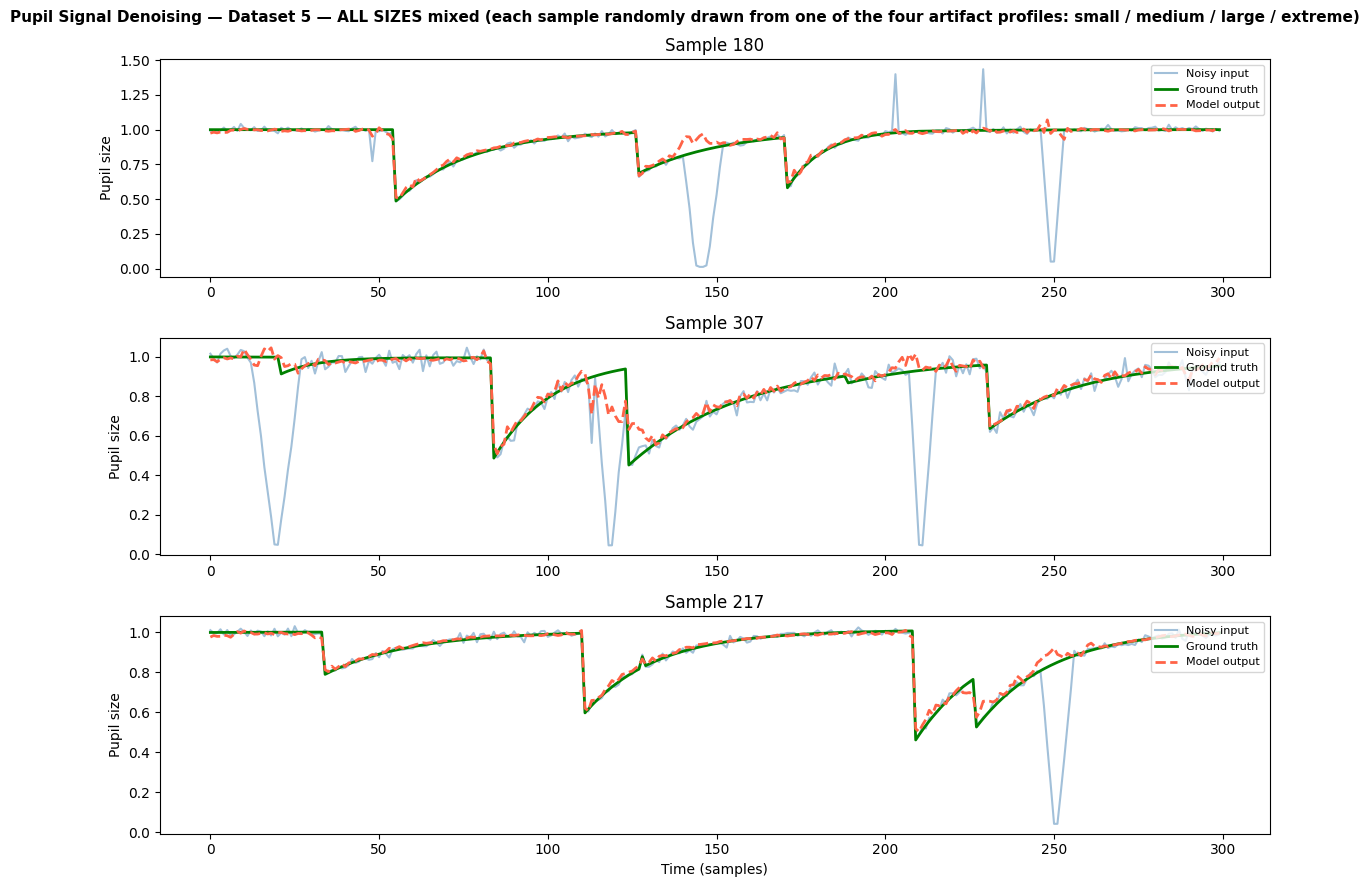

Saved predictions_model5_medium.png

  PRETRAINING COMPLETE — Model 5 (medium)
  Checkpoint : model5_all.pt
  Dataset    : dataset_model5_all.npz

  NEXT STEPS — run this script 4 more times, changing ARTIFACT_SIZE each time:

    ARTIFACT_SIZE = "small"    →  saves model1_small.pt    + dataset_model1_small.npz
    ARTIFACT_SIZE = "medium"   →  saves model2_medium.pt   + dataset_model2_medium.npz
    ARTIFACT_SIZE = "large"    →  saves model3_large.pt    + dataset_model3_large.npz
    ARTIFACT_SIZE = "extreme"  →  saves model4_extreme.pt  + dataset_model4_extreme.npz
    ARTIFACT_SIZE = "all"      →  saves model5_all.pt      + dataset_model5_all.npz

  Then use load_all_five_models() and ensemble_predict() on your real data.



In [14]:
# ─────────────────────────────────────────────
# 8. MAIN — SINGLE-MODEL TRAINING SCRIPT
#    Run this script once per ARTIFACT_SIZE to
#    pretrain each of the 5 models separately.
# ─────────────────────────────────────────────

if __name__ == "__main__":

    # ── Configuration ─────────────────────────────────────────────────────────
    N_SAMPLES     = 400    # was 1000 — fewer samples, still representative
    SIGNAL_LENGTH = 300
    SEED          = 42
    BATCH_SIZE    = 64    # was 32  — larger batches = fewer optimizer steps per epoch
    N_EPOCHS      = 30    # was 50  — early stopping usually kicks in before this anyway
    LR            = 3e-3  # was 1e-3 — faster convergence on CPU
    VAL_FRACTION  = 0.2
    DEVICE        = "cpu"

    print(f"\n  Device : {DEVICE}")
    print(f"  Running pretraining for Model {MODEL_INDEX} "
          f"(artifact size = '{ARTIFACT_SIZE}')\n")

    # ── Step 1: Generate the dataset for this model ───────────────────────────
    print("  [Step 1/4] Generating synthetic dataset …")
    noisy, clean = generate_dataset(
        artifact_size = ARTIFACT_SIZE,
        n_samples     = N_SAMPLES,
        signal_length = SIGNAL_LENGTH,
        seed          = SEED,
        save_path     = DATASET_SAVE_PATH,   # saves to e.g. "dataset_model2_medium.npz"
    )
    print(f"  noisy shape: {noisy.shape}  |  clean shape: {clean.shape}")

    # ── Step 2: Build DataLoaders ──────────────────────────────────────────────
    print("\n  [Step 2/4] Building DataLoaders …")
    n_val    = int(len(noisy) * VAL_FRACTION)
    n_train  = len(noisy) - n_val
    full_ds  = PupilDataset(noisy, clean)

    train_ds, val_ds = torch.utils.data.random_split(
        full_ds, [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED),
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    print(f"  Train samples: {n_train}  |  Val samples: {n_val}")

    # ── Step 3: Instantiate and train the model ────────────────────────────────
    print(f"\n  [Step 3/4] Training Model {MODEL_INDEX} …")
    model   = PupilDenoisingCNN(base_channels=16, n_residual_blocks=2)  # was (32, 4) — ~6× fewer parameters
    history = train(
        model,
        train_loader,
        val_loader,
        model_save_path = MODEL_SAVE_PATH,   # e.g. "model2_medium.pt"
        n_epochs        = N_EPOCHS,
        lr              = LR,
        device          = DEVICE,
        patience        = 10,
    )

    # ── Step 4: Visualise results ──────────────────────────────────────────────
    print(f"\n  [Step 4/4] Plotting results for Model {MODEL_INDEX} …")
    plot_predictions(
        model    = model,
        noisy_np = noisy,
        clean_np = clean,
        n_examples = 3,
        device     = DEVICE,
    )

    # ── Summary ───────────────────────────────────────────────────────────────
    print("\n" + "=" * 70)
    print(f"  PRETRAINING COMPLETE — Model {MODEL_INDEX} ({ARTIFACT_SIZE})")
    print(f"  Checkpoint : {MODEL_SAVE_PATH}")
    print(f"  Dataset    : {DATASET_SAVE_PATH}")
    print("=" * 70)
    print("""
  NEXT STEPS — run this script 4 more times, changing ARTIFACT_SIZE each time:

    ARTIFACT_SIZE = "small"    →  saves model1_small.pt    + dataset_model1_small.npz
    ARTIFACT_SIZE = "medium"   →  saves model2_medium.pt   + dataset_model2_medium.npz
    ARTIFACT_SIZE = "large"    →  saves model3_large.pt    + dataset_model3_large.npz
    ARTIFACT_SIZE = "extreme"  →  saves model4_extreme.pt  + dataset_model4_extreme.npz
    ARTIFACT_SIZE = "all"      →  saves model5_all.pt      + dataset_model5_all.npz

  Then use load_all_five_models() and ensemble_predict() on your real data.
""")

  Generating 6 samples for each of the 5 datasets …

  ── Dataset 1 — SMALL artifacts ──
  Saved viz_model1_small.png


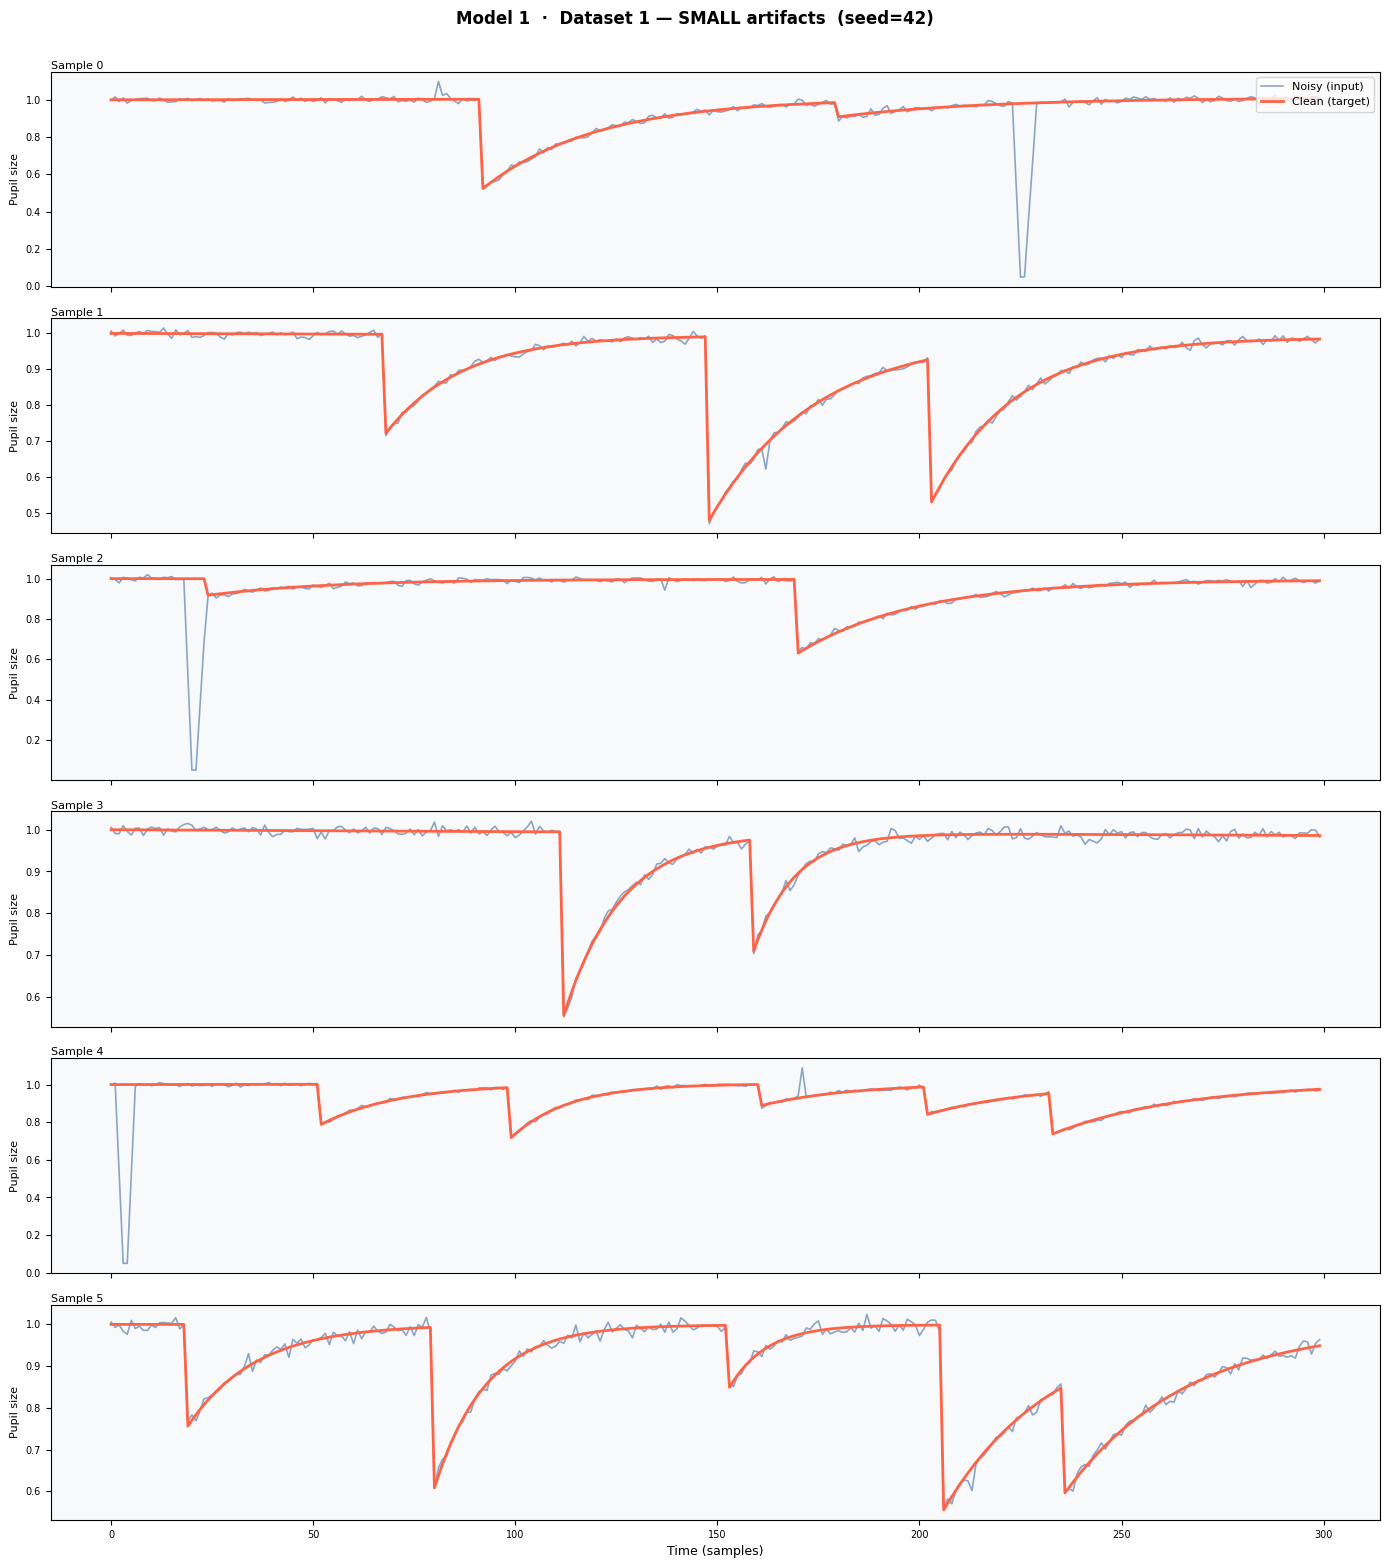


  ── Dataset 2 — MEDIUM artifacts ──
  Saved viz_model2_medium.png


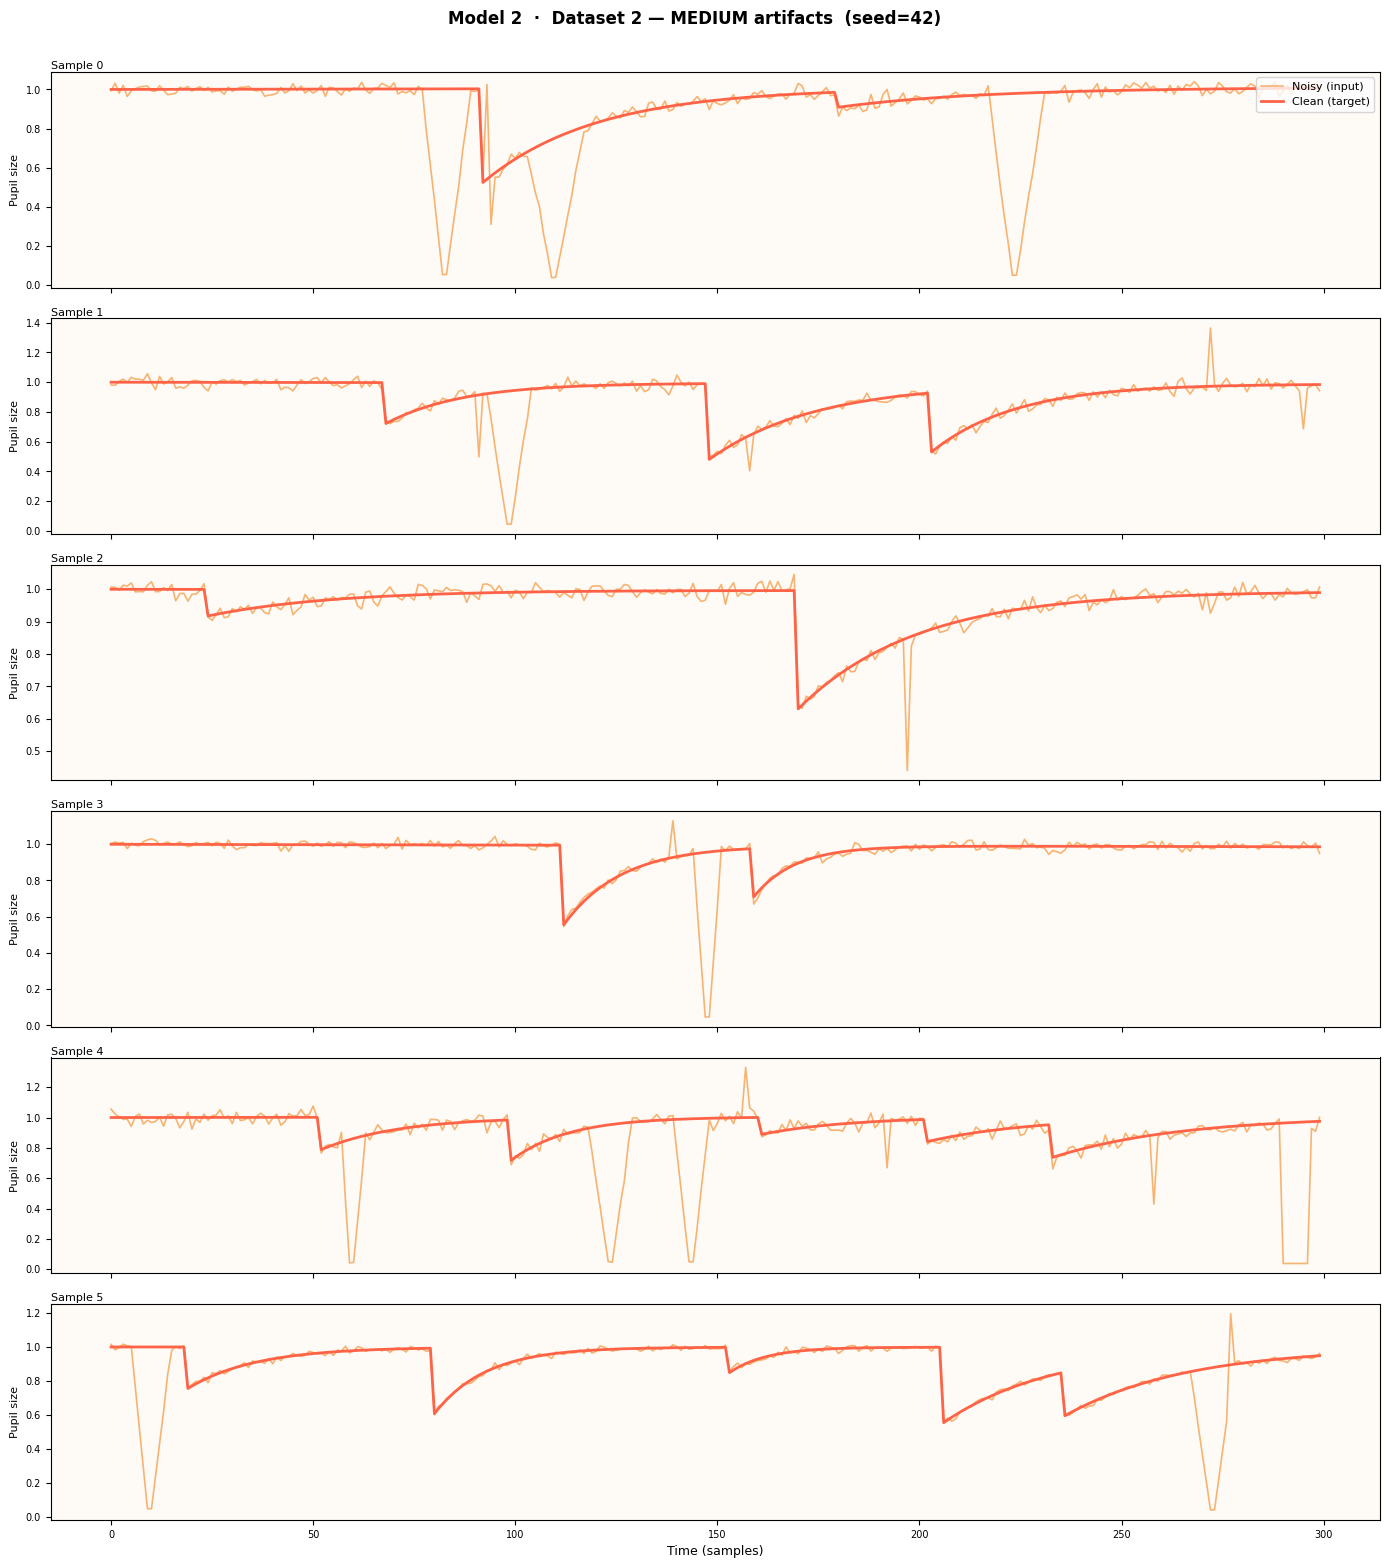


  ── Dataset 3 — LARGE artifacts ──
  Saved viz_model3_large.png


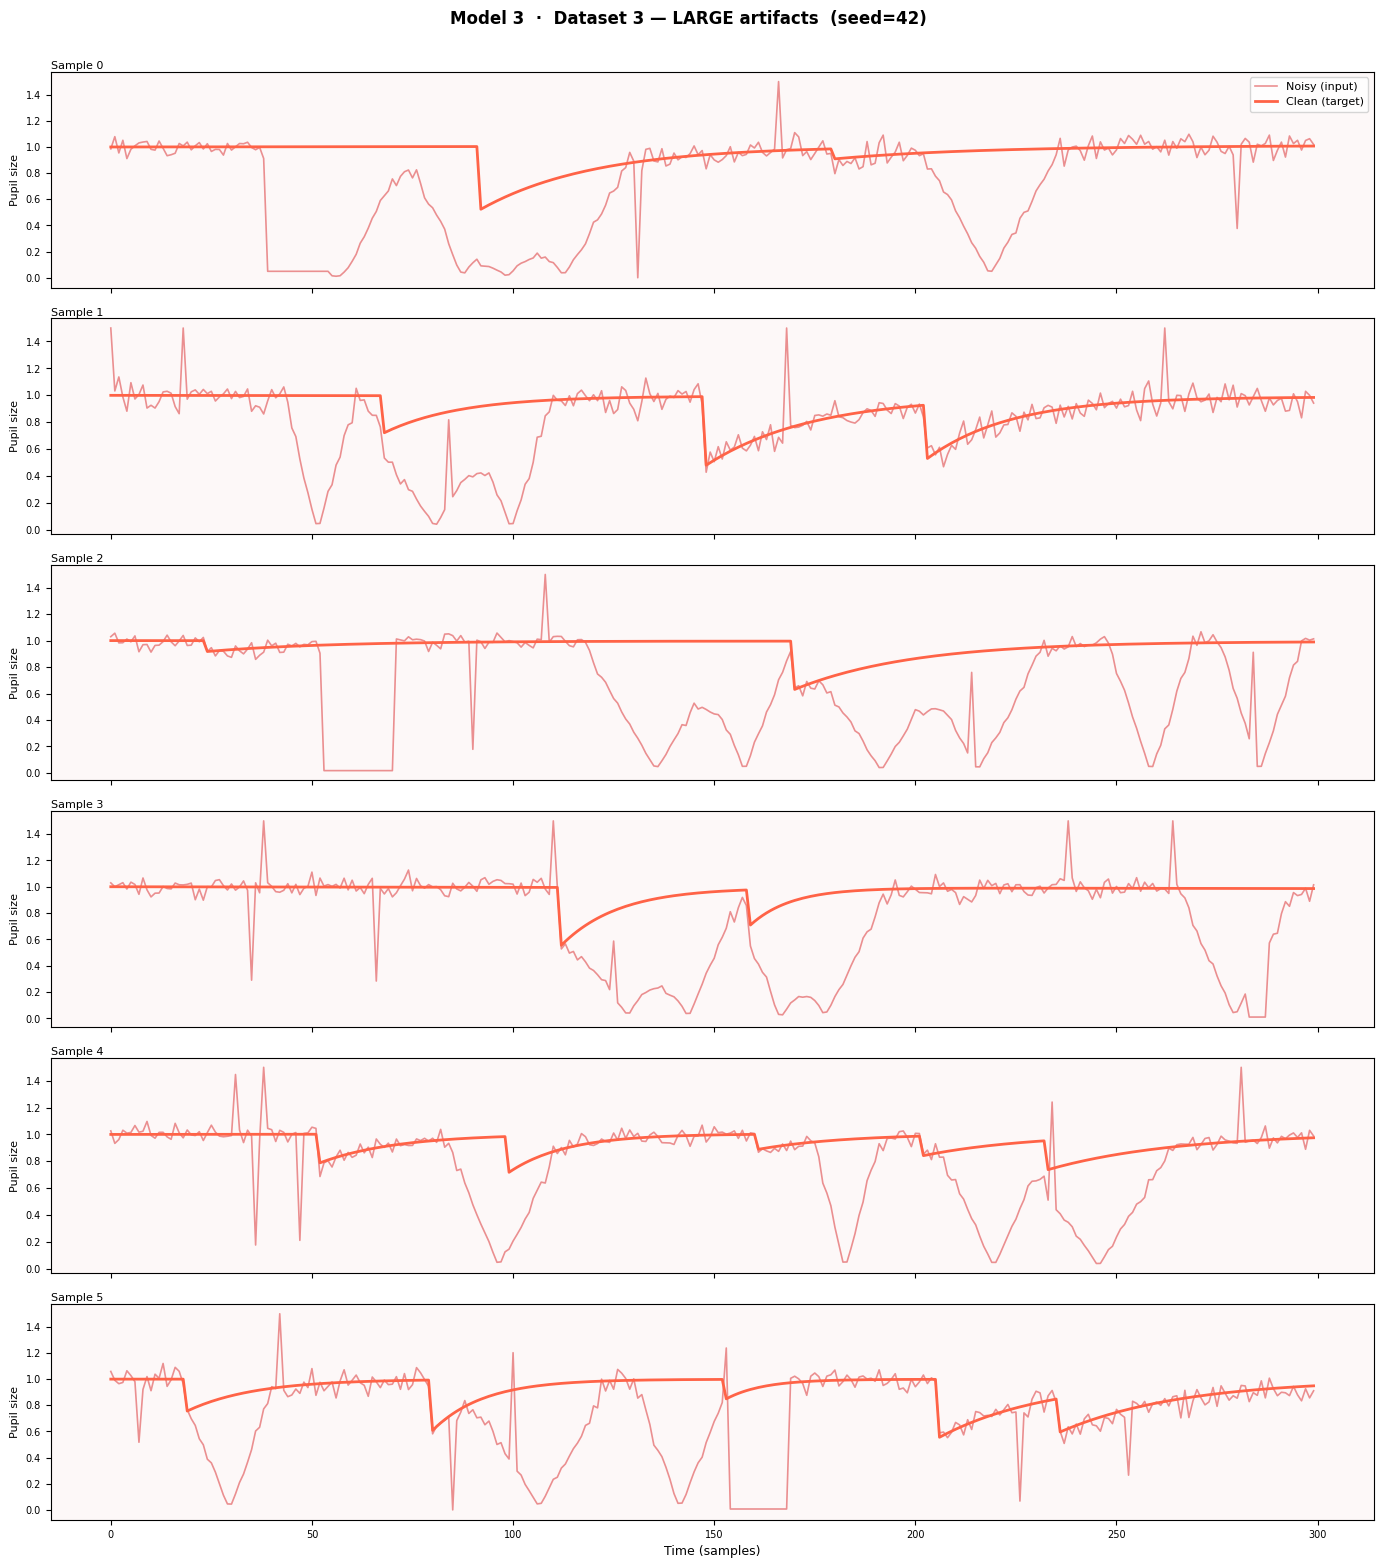


  ── Dataset 4 — EXTREME artifacts ──
  Saved viz_model4_extreme.png


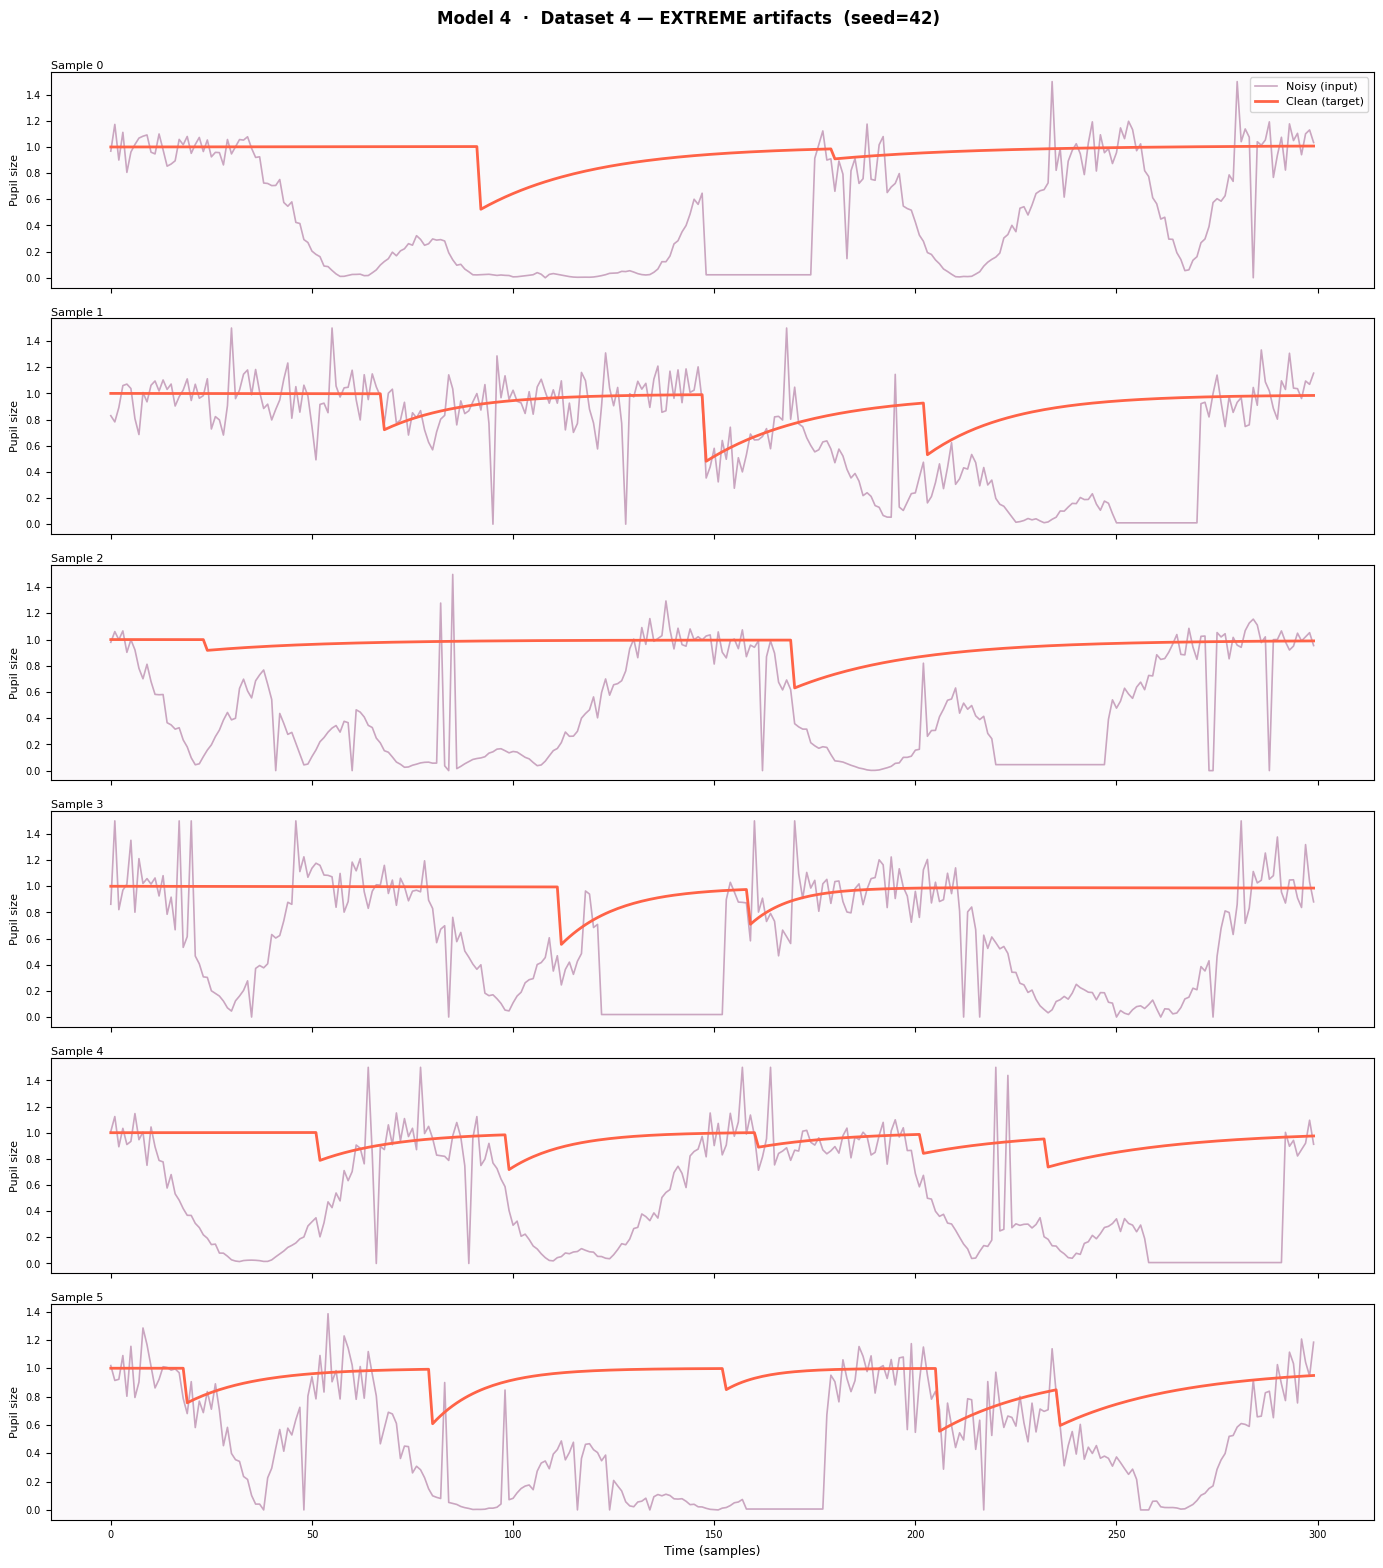


  ── Dataset 5 — ALL SIZES mixed ──
  Saved viz_model5_all.png


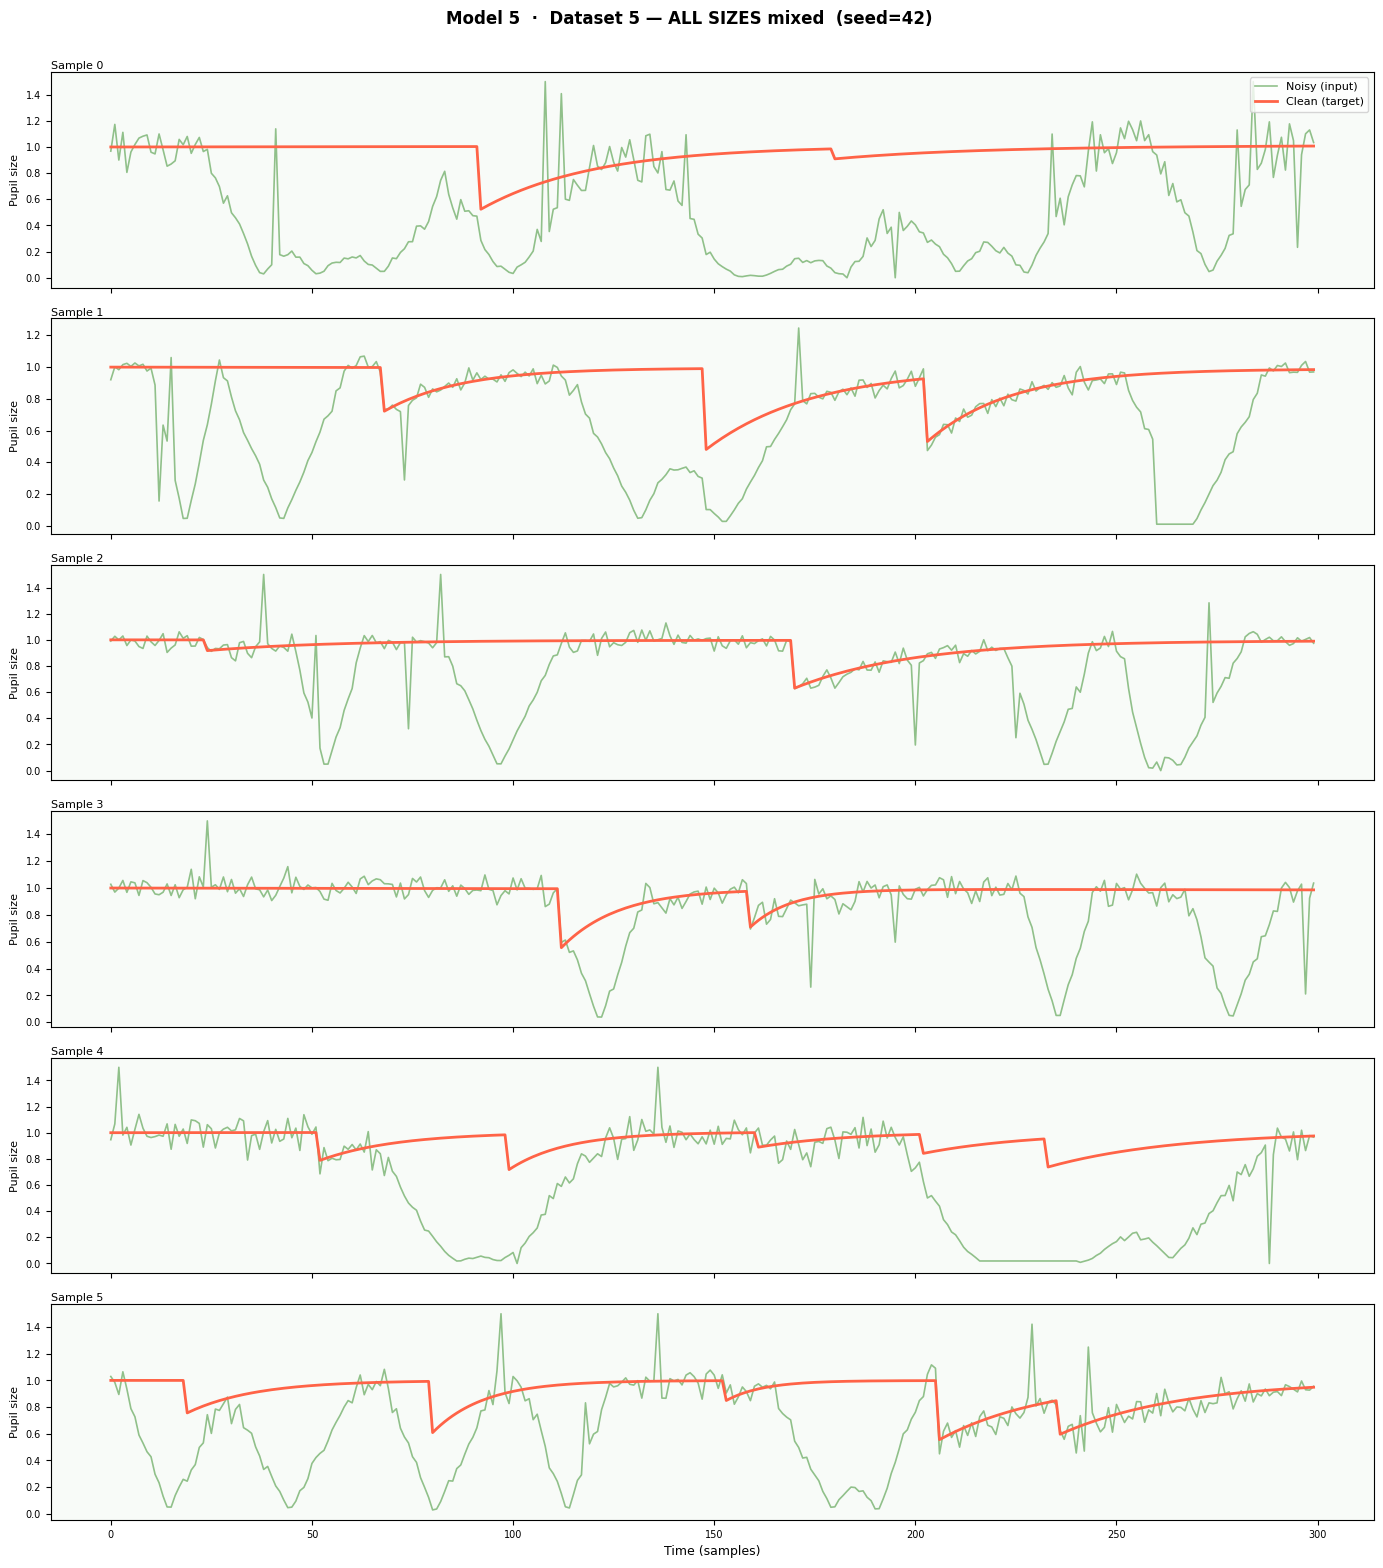


  Generating overlay comparison for sample 0 …
  Saved viz_overlay_all5.png


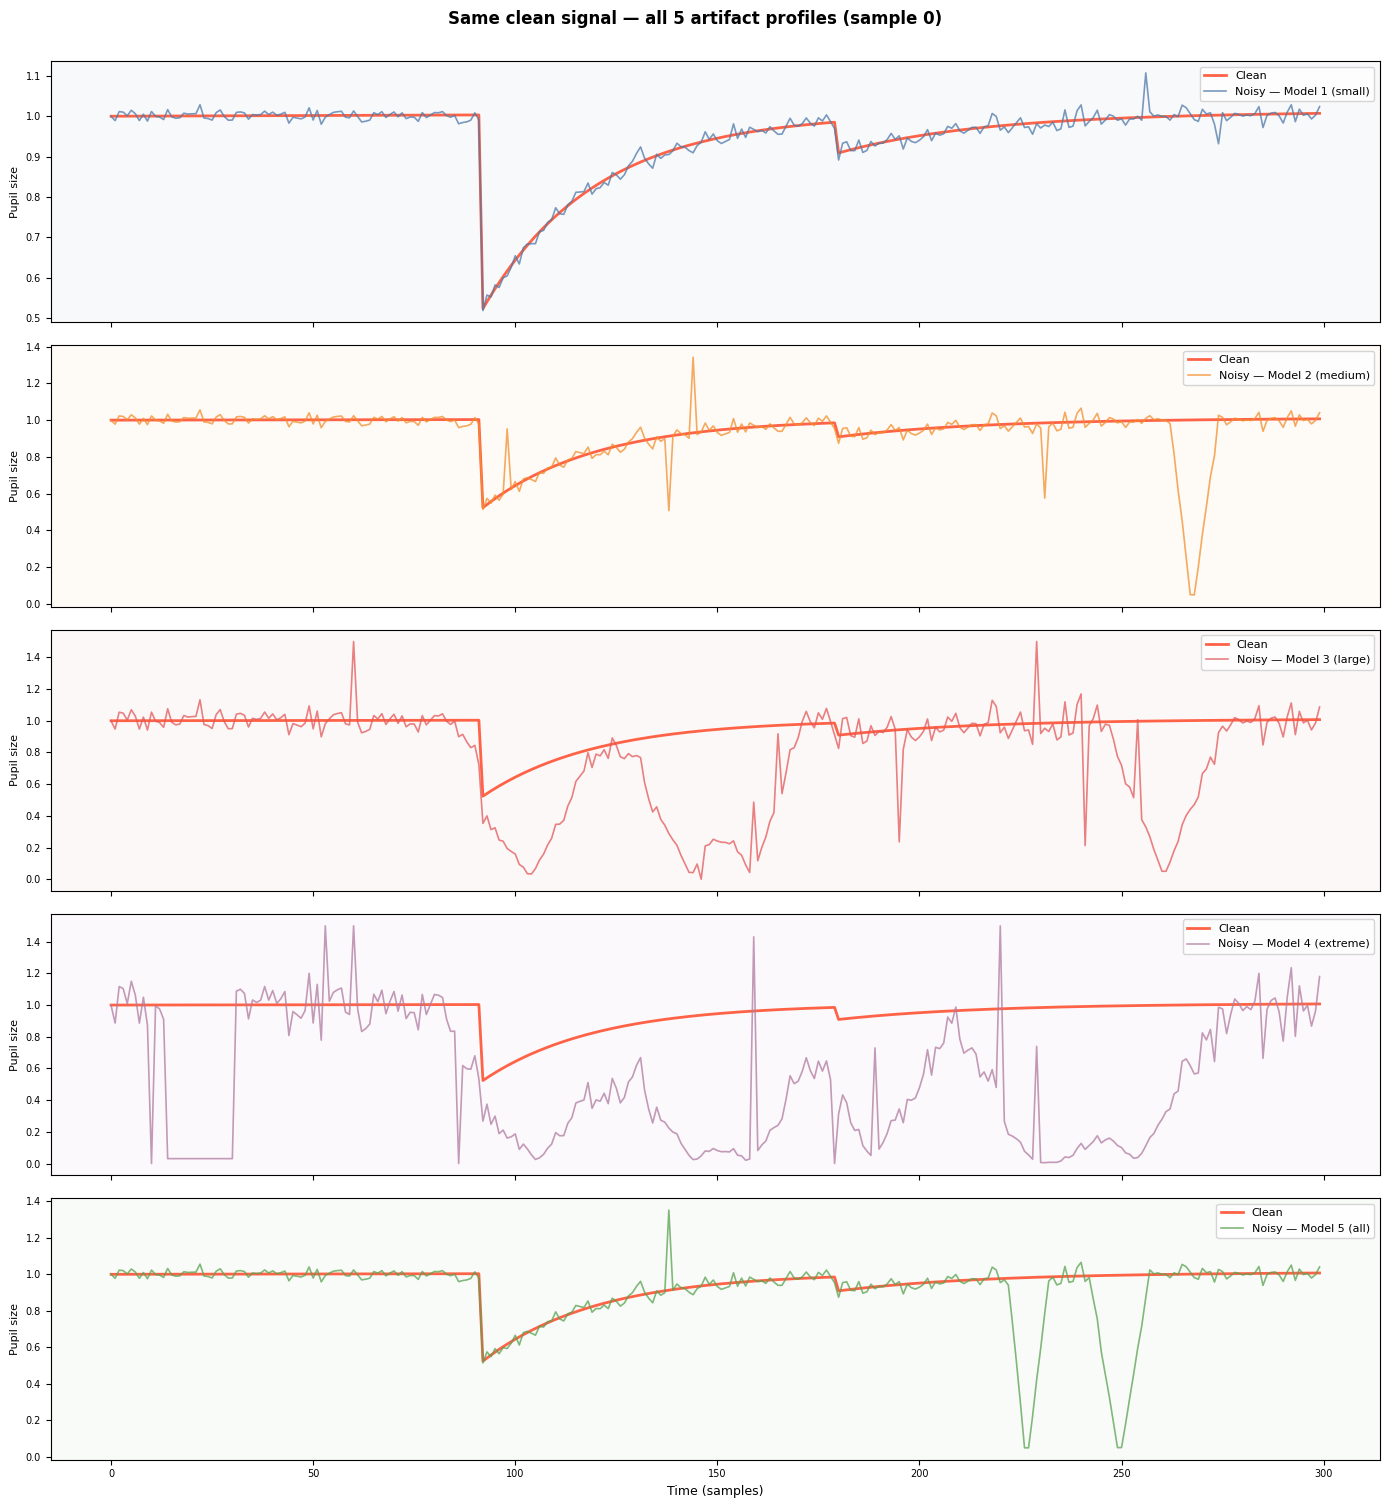

In [15]:
"""
Visualizer — 5-Model Ensemble Pipeline
=======================================
Shows clean vs noisy pairs for each of the 5 dataset configurations.

TWO MODES (set VIZ_MODE below):
  "single"    → visualise only the dataset for the currently selected
                 ARTIFACT_SIZE (mirrors what you'd train one model on)
  "all_five"  → one figure per dataset, side-by-side comparison of all 5

Make sure ARTIFACT_SIZE here matches the one in pupil_pipeline_5models.py,
or just import the constants directly if running from the same file.
"""

import numpy as np
import matplotlib.pyplot as plt

# ── paste or import from pupil_pipeline_5models.py ───────────────────────────
# from pupil_pipeline_5models import (
#     generate_dataset, ARTIFACT_PROFILES, ARTIFACT_SIZE,
#     MODEL_INDEX, ACTIVE_PROFILE_DESCRIPTION, _SIZE_TO_MODEL_INDEX
# )

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIG — change these to control what is visualised
# ═══════════════════════════════════════════════════════════════════════════════

# *** Set to the same value as ARTIFACT_SIZE in pupil_pipeline_5models.py ***
# Only used when VIZ_MODE = "single"
ARTIFACT_SIZE = "medium"   # "small" | "medium" | "large" | "extreme" | "all"

# "single"   → one figure for ARTIFACT_SIZE above
# "all_five" → one figure per dataset (all 5 sizes), great for comparison
VIZ_MODE = "all_five"      # "single" | "all_five"

N_SAMPLES     = 6      # examples per figure (keep ≤ 12 for readability)
SIGNAL_LENGTH = 300    # must match training config

# ═══════════════════════════════════════════════════════════════════════════════

# Colour palette — one accent colour per dataset
_PALETTE = {
    "small":   "#4e79a7",
    "medium":  "#f28e2b",
    "large":   "#e15759",
    "extreme": "#b07aa1",
    "all":     "#59a14f",
}

_SIZE_TO_MODEL_INDEX = {"small": 1, "medium": 2, "large": 3, "extreme": 4, "all": 5}

_DESCRIPTIONS = {
    "small":   "Dataset 1 — SMALL artifacts",
    "medium":  "Dataset 2 — MEDIUM artifacts",
    "large":   "Dataset 3 — LARGE artifacts",
    "extreme": "Dataset 4 — EXTREME artifacts",
    "all":     "Dataset 5 — ALL SIZES mixed",
}


def _plot_dataset(noisy_all, clean_all, artifact_size, seed):
    """Draw one figure: N_SAMPLES rows, clean vs noisy for one dataset."""
    n         = len(noisy_all)
    midx      = _SIZE_TO_MODEL_INDEX[artifact_size]
    accent    = _PALETTE[artifact_size]
    desc      = _DESCRIPTIONS[artifact_size]

    fig, axes = plt.subplots(n, 1, figsize=(14, 2.6 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.plot(noisy_all[i], color=accent,   alpha=0.65, lw=1.2, label="Noisy (input)")
        ax.plot(clean_all[i], color="tomato", lw=2,       label="Clean (target)")
        ax.set_ylabel("Pupil size", fontsize=8)
        ax.set_title(f"Sample {i}", fontsize=8, loc="left", pad=2)
        ax.tick_params(labelsize=7)
        # Subtle background stripe to tell figures apart at a glance
        ax.set_facecolor((*plt.matplotlib.colors.to_rgb(accent), 0.04))
        if i == 0:
            ax.legend(loc="upper right", fontsize=8)

    axes[-1].set_xlabel("Time (samples)", fontsize=9)
    fig.suptitle(
        f"Model {midx}  ·  {desc}  (seed={seed})",
        fontsize=12, fontweight="bold", y=1.002,
    )
    plt.tight_layout()
    fname = f"viz_model{midx}_{artifact_size}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"  Saved {fname}")
    plt.show()


# ─────────────────────────────────────────────
# SINGLE MODE — one dataset / one model
# ─────────────────────────────────────────────
if VIZ_MODE == "single":
    SEED = 42
    print(f"  Generating {N_SAMPLES} samples for '{ARTIFACT_SIZE}' …")
    noisy_all, clean_all = generate_dataset(
        artifact_size = ARTIFACT_SIZE,
        n_samples     = N_SAMPLES,
        signal_length = SIGNAL_LENGTH,
        seed          = SEED,
    )
    _plot_dataset(noisy_all, clean_all, ARTIFACT_SIZE, SEED)


# ─────────────────────────────────────────────
# ALL-FIVE MODE — one figure per dataset
# ─────────────────────────────────────────────
elif VIZ_MODE == "all_five":
    ALL_SIZES = ["small", "medium", "large", "extreme", "all"]
    SEED      = 42   # same seed → same clean signals, only artifacts differ

    print(f"  Generating {N_SAMPLES} samples for each of the 5 datasets …\n")
    for size in ALL_SIZES:
        print(f"  ── {_DESCRIPTIONS[size]} ──")
        noisy_all, clean_all = generate_dataset(
            artifact_size = size,
            n_samples     = N_SAMPLES,
            signal_length = SIGNAL_LENGTH,
            seed          = SEED,      # identical seed → same underlying clean signals
        )
        _plot_dataset(noisy_all, clean_all, size, SEED)
        print()

    # ── Bonus: side-by-side overlay for one shared sample ────────────────────
    #    Shows how the same clean signal looks under each artifact profile.
    print("  Generating overlay comparison for sample 0 …")
    SAMPLE_IDX = 0
    fig, axes  = plt.subplots(len(ALL_SIZES), 1, figsize=(14, 3 * len(ALL_SIZES)), sharex=True)

    for ax, size in zip(axes, ALL_SIZES):
        noisy_s, clean_s = generate_dataset(
            artifact_size = size,
            n_samples     = max(SAMPLE_IDX + 1, 1),
            signal_length = SIGNAL_LENGTH,
            seed          = SEED,
        )
        midx   = _SIZE_TO_MODEL_INDEX[size]
        accent = _PALETTE[size]
        ax.plot(clean_s[SAMPLE_IDX],  color="tomato", lw=2,       label="Clean")
        ax.plot(noisy_s[SAMPLE_IDX],  color=accent,   alpha=0.75, lw=1.2,
                label=f"Noisy — Model {midx} ({size})")
        ax.set_ylabel("Pupil size", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_facecolor((*plt.matplotlib.colors.to_rgb(accent), 0.04))
        ax.legend(loc="upper right", fontsize=8)

    axes[-1].set_xlabel("Time (samples)", fontsize=9)
    fig.suptitle(
        f"Same clean signal — all 5 artifact profiles (sample {SAMPLE_IDX})",
        fontsize=12, fontweight="bold", y=1.002,
    )
    plt.tight_layout()
    fname = "viz_overlay_all5.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"  Saved {fname}")
    plt.show()

else:
    raise ValueError(f"VIZ_MODE must be 'single' or 'all_five'. Got: '{VIZ_MODE}'")

In [16]:
# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ CELL 2 — Load the 5 saved models                                            │
# │ Run once per session, after the big training chunk.                          │
# └──────────────────────────────────────────────────────────────────────────────┘
 
# PupilDenoisingCNN and load_all_five_models() are already defined above —
# we just call the loader with the correct architecture (base_channels=16, n_residual_blocks=2)
# to match what was actually used during pretraining.
 
models = load_all_five_models(base_channels=16, n_residual_blocks=2)
 
print(f"\n  {len(models)}/5 models ready.")

  Loaded Model (  small) ← model1_small.pt
  Loaded Model ( medium) ← model2_medium.pt
  Loaded Model (  large) ← model3_large.pt
  Loaded Model (extreme) ← model4_extreme.pt
  Loaded Model (    all) ← model5_all.pt

  5/5 models ready.


In [ ]:
# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ CELL 3 — Run inference on your real data                                     │
# │ Replace `your_real_data` with your actual (N, 300) float32 numpy array.     │
# │ Each row = one trial / epoch of 300 samples.                                 │
# └──────────────────────────────────────────────────────────────────────────────┘
 
# ── Plug your data in here ─────────────────────────────────────────────────────
your_real_data = np.load("your_real_data.npy").astype(np.float32)  # shape (N, 300)
# your_real_data = ...   ← or build the array however fits your pipeline
 
print(f"  Input shape: {your_real_data.shape}  →  {your_real_data.shape[0]} trials")
 
# ── Run each model separately ──────────────────────────────────────────────────
 
predictions = {}   # keyed by artifact size, each value is (N, 300) float32
 
with torch.no_grad():
    x = torch.from_numpy(your_real_data[:, None, :])   # (N, 1, 300)
 
    for size, model in models.items():
        pred = model(x).numpy()[:, 0, :]               # (N, 300)
        predictions[size] = pred
        print(f"  Model {MODEL_INDEX[size]} ({size:>7})  →  output shape: {pred.shape}")
 
# predictions["small"]   → denoised by Model 1
# predictions["medium"]  → denoised by Model 2
# predictions["large"]   → denoised by Model 3
# predictions["extreme"] → denoised by Model 4
# predictions["all"]     → denoised by Model 5
 
# ── Plot all 5 outputs for one trial ──────────────────────────────────────────
 
TRIAL_IDX = 0   # ← change to inspect a different trial
 
fig, axes = plt.subplots(len(predictions) + 1, 1,
                         figsize=(14, 3 * (len(predictions) + 1)), sharex=True)
 
axes[0].plot(your_real_data[TRIAL_IDX], color="gray", lw=1.2, label="Raw input")
axes[0].set_title("Raw input", fontsize=9, loc="left")
axes[0].set_ylabel("Pupil size", fontsize=8)
axes[0].legend(fontsize=8)
 
PALETTE = {"small": "#4e79a7", "medium": "#f28e2b", "large": "#e15759",
           "extreme": "#b07aa1", "all": "#59a14f"}
 
for ax, (size, pred) in zip(axes[1:], predictions.items()):
    ax.plot(your_real_data[TRIAL_IDX], color="gray",        alpha=0.35, lw=1)
    ax.plot(pred[TRIAL_IDX],           color=PALETTE[size], lw=2,
            label=f"Model {MODEL_INDEX[size]} ({size})")
    ax.set_ylabel("Pupil size", fontsize=8)
    ax.set_title(f"Model {MODEL_INDEX[size]} — {size} artifacts", fontsize=9, loc="left")
    ax.legend(fontsize=8, loc="upper right")
 
axes[-1].set_xlabel("Time (samples)", fontsize=9)
plt.suptitle(f"5-Model outputs — Trial {TRIAL_IDX}", fontsize=12, fontweight="bold", y=1.002)
plt.tight_layout()
plt.savefig(f"inference_trial{TRIAL_IDX}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved inference_trial{TRIAL_IDX}.png")